**Eight notebooks** cover the workflow sequence:
1. [create_datasets_yf.ipynb](01_create_datasets_yf.ipynb) : creates datasets using yfinance
2. [sentiment_feature_building](02_sentiment_feature_building.ipynb): (optional) we calculate the sentiment using finbert on financial news
3. [feature_engineering_yf](03_feature_engineering_yf.ipynb): we compute features from data to later feed into the model
4. [optimizing_xgboost](04_optimizing_xgboost.ipynb): we train a xgboost model to predict returns
5. `evaluate_xgboost`(this notebook): we compare the cross-validation performance using various metrics to select the best model. 
6. [model_interpretation](06_model_interpretation.ipynb): we take a closer look at the drivers behind the best model's predictions.
7. [making_out_of_sample_predictions](07_making_out_of_sample_predictions.ipynb): we predict returns for our out-of-sample period
8. [backtest_backtrader](08_backtest_backtrader.ipynb): evaluate the historical performance of our strategy based on our predictive signals

Cross-validation of numerous configurations has produced a large number of results. Now, we need to evaluate the predictive performance to identify the model that generates the most reliable and profitable signals for our prospective trading strategy.

## Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
%matplotlib inline

from time import time
from io import StringIO
import sys, os
import warnings
from pathlib import Path
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost  as xgb
import numpy as np

from scipy.stats import spearmanr, pearsonr


In [3]:
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
from utils import MultipleTimeSeriesCV

In [4]:
sns.set_style('whitegrid')

In [5]:
YEAR = 252
idx = pd.IndexSlice

In [6]:
scope_params = ['lookahead', 'train_length', 'test_length']
daily_ic_metrics = ['daily_ic_mean', 'daily_ic_mean_n', 'daily_ic_median', 'daily_ic_median_n']
xgb_train_params = ['learning_rate', 'max_depth', 'n_estimators', 'alpha']
xgb_loss_params = ['avg_overfitting_ratio','avg_best_iteration','final_train_loss','final_valid_loss']


In [7]:
results_path = Path('results')
if not results_path.exists():
    results_path.mkdir(parents=True)

## Collect Data

### XGBoost

#### Summary Metrics by Fold

First, we collect the summary metrics computed for each fold and hyperparameter combination:

In [8]:
with pd.HDFStore(results_path / 'tuning_xgb.h5') as store:
    for i, key in enumerate(
        [k[1:] for k in store.keys() if k[1:].startswith('metrics')]):
        _, t, train_length, test_length = key.split('/')[:4]
        attrs = {
            'lookahead': t,
            'train_length': train_length,
            'test_length': test_length
        }
        s = store[key].to_dict()
        s.update(attrs)
        # check that I have all the parameters
        if "alpha" not in s:
            continue
        if i == 0:
            xgb_metrics = pd.Series(s).to_frame(i)
        else:
            xgb_metrics[i] = pd.Series(s)

id_vars = scope_params + xgb_train_params + daily_ic_metrics + xgb_loss_params
xgb_metrics = pd.melt(xgb_metrics.T.drop('t', axis=1), 
                  id_vars=id_vars, 
                  value_name='ic', 
                  var_name='boost_rounds').dropna().apply(pd.to_numeric)

In [9]:
xgb_metrics.to_hdf('data/model_tuning.h5', 'xgb/metrics')
xgb_metrics.info()

<class 'pandas.core.frame.DataFrame'>
Index: 456 entries, 0 to 578
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   lookahead              456 non-null    int64  
 1   train_length           456 non-null    int64  
 2   test_length            456 non-null    int64  
 3   learning_rate          456 non-null    float64
 4   max_depth              456 non-null    float64
 5   n_estimators           456 non-null    float64
 6   alpha                  456 non-null    float64
 7   daily_ic_mean          456 non-null    float64
 8   daily_ic_mean_n        456 non-null    float64
 9   daily_ic_median        456 non-null    float64
 10  daily_ic_median_n      456 non-null    float64
 11  avg_overfitting_ratio  456 non-null    float64
 12  avg_best_iteration     456 non-null    float64
 13  final_train_loss       456 non-null    float64
 14  final_valid_loss       456 non-null    float64
 15  boost_round

In [10]:
xgb_metrics.groupby(scope_params).size()

lookahead  train_length  test_length
1          1134          21              84
                         63             150
5          1134          21              57
                         63              51
21         1134          21              51
                         63              63
dtype: int64

#### Information Coefficient by Day

Next, we retrieve the IC per day computed during cross-validation:

In [11]:
int_cols = ['lookahead', 'train_length', 'test_length', 'boost_rounds']

In [12]:
with pd.HDFStore(results_path / 'tuning_xgb.h5') as store:
    print(store.keys())

['/predictions/5/252/63/0.3/3', '/predictions/5/252/63/0.3/5', '/predictions/5/252/63/0.1/2', '/predictions/5/252/63/0.1/3', '/predictions/5/252/63/0.1/5', '/predictions/5/252/63/0.01/3', '/predictions/5/252/63/0.01/5', '/predictions/5/252/21/0.1/2', '/predictions/5/252/21/0.1/3', '/predictions/5/252/21/0.01/3', '/predictions/5/252/21/0.01/5', '/predictions/5/1134/63/0.3/3', '/predictions/5/1134/63/0.3/5', '/predictions/5/1134/63/0.1/3', '/predictions/5/1134/63/0.1/5', '/predictions/5/1134/63/0.1/5/300/0', '/predictions/5/1134/63/0.1/5/300/1', '/predictions/5/1134/63/0.1/5/100/0', '/predictions/5/1134/63/0.1/5/100/1', '/predictions/5/1134/63/0.1/5/100/10', '/predictions/5/1134/63/0.1/3/500/10', '/predictions/5/1134/63/0.1/3/300/0', '/predictions/5/1134/63/0.1/3/300/10', '/predictions/5/1134/63/0.1/3/100/0', '/predictions/5/1134/63/0.1/3/100/1', '/predictions/5/1134/63/0.1/2/300/0', '/predictions/5/1134/63/0.1/2/300/1', '/predictions/5/1134/63/0.1/2/100/1', '/predictions/5/1134/63/0.01/

In [13]:
xgb_ic = []
with pd.HDFStore(results_path / 'tuning_xgb.h5') as store:
    keys = [k[1:] for k in store.keys()]
    for key in keys:
        _, t, train_length, test_length = key.split('/')[:4]
        if key.startswith('daily_ic'):
            df = (store[key]
                  #.drop(['boosting', 'objective', 'verbose'], axis=1)
                  .drop(['booster', 'objective', 'verbosity'], axis=1)
                 .assign(lookahead=t, 
                         train_length=train_length, 
                         test_length=test_length))
            xgb_ic.append(df)
    xgb_ic = pd.concat(xgb_ic).reset_index()

In [14]:
xgb_ic

,date,10,25,50,75,100,150,200,250,300,...,400,450,500,learning_rate,max_depth,lookahead,train_length,test_length,n_estimators,alpha
0,2023-03-23,0.355480,0.296243,0.173077,0.152853,0.112323,0.144048,0.085488,0.096089,0.104357,...,0.084846,0.093964,0.094313,0.30,3,5,252,63,NaN,NaN
1,2023-03-24,0.182012,0.035806,0.023855,-0.025847,-0.018165,-0.018542,-0.023035,-0.001757,0.005552,...,0.001829,-0.001228,0.003940,0.30,3,5,252,63,NaN,NaN
2,2023-03-27,-0.008796,-0.087995,-0.056358,-0.016450,0.014536,0.002387,0.083679,0.095261,0.096781,...,0.086391,0.083273,0.102776,0.30,3,5,252,63,NaN,NaN
3,2023-03-28,-0.053163,-0.113662,-0.102186,-0.090273,-0.058231,-0.060148,0.037485,0.035350,0.043691,...,0.029908,0.009135,0.018756,0.30,3,5,252,63,NaN,NaN
4,2023-03-29,0.124617,-0.015808,-0.051311,-0.019866,-0.006290,0.002108,-0.016630,-0.043375,0.009568,...,0.005869,0.006512,0.015288,0.30,3,5,252,63,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140107,2024-11-22,0.196232,NaN,0.206261,NaN,0.271439,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.01,2,1,1134,21,100.0,10.0
140108,2024-11-25,-0.120912,NaN,-0.120912,NaN,-0.256003,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.01,2,1,1134,21,100.0,10.0
140109,2024-11-26,0.196130,NaN,0.183926,NaN,0.209712,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.01,2,1,1134,21,100.0,10.0
140110,2024-11-27,-0.059159,NaN,-0.048528,NaN,0.017124,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.01,2,1,1134,21,100.0,10.0


In [15]:
id_vars = ['date'] + scope_params + xgb_train_params
xgb_ic = pd.melt(xgb_ic, 
                 id_vars=id_vars, 
                 value_name='ic', 
                 var_name='boost_rounds').dropna()
xgb_ic.loc[:, int_cols] = xgb_ic.loc[:, int_cols].astype(int)

In [16]:
xgb_ic.to_hdf('data/model_tuning.h5', 'xgb/ic')
xgb_ic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389645 entries, 7560 to 1260503
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           389645 non-null  datetime64[ns]
 1   lookahead      389645 non-null  object        
 2   train_length   389645 non-null  object        
 3   test_length    389645 non-null  object        
 4   learning_rate  389645 non-null  float64       
 5   max_depth      389645 non-null  int64         
 6   n_estimators   389645 non-null  float64       
 7   alpha          389645 non-null  float64       
 8   boost_rounds   389645 non-null  object        
 9   ic             389645 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(4)
memory usage: 32.7+ MB


In [17]:
xgb_daily_ic = xgb_ic.groupby(id_vars[1:] + ['boost_rounds']).ic.mean().to_frame('ic').reset_index()
xgb_daily_ic.to_hdf('data/model_tuning.h5', 'xgb/daily_ic')
xgb_daily_ic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 781 entries, 0 to 780
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   lookahead      781 non-null    int64  
 1   train_length   781 non-null    int64  
 2   test_length    781 non-null    int64  
 3   learning_rate  781 non-null    float64
 4   max_depth      781 non-null    int64  
 5   n_estimators   781 non-null    float64
 6   alpha          781 non-null    float64
 7   boost_rounds   781 non-null    int64  
 8   ic             781 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 55.0 KB


In [18]:
xgb_ic = pd.read_hdf('data/model_tuning.h5', 'xgb/ic')
xgb_daily_ic = pd.read_hdf('data/model_tuning.h5', 'xgb/daily_ic')

## Validation Performance: Daily vs Overall Information Coefficient

The following image shows that that xgb performs better for  for longer horizons. 


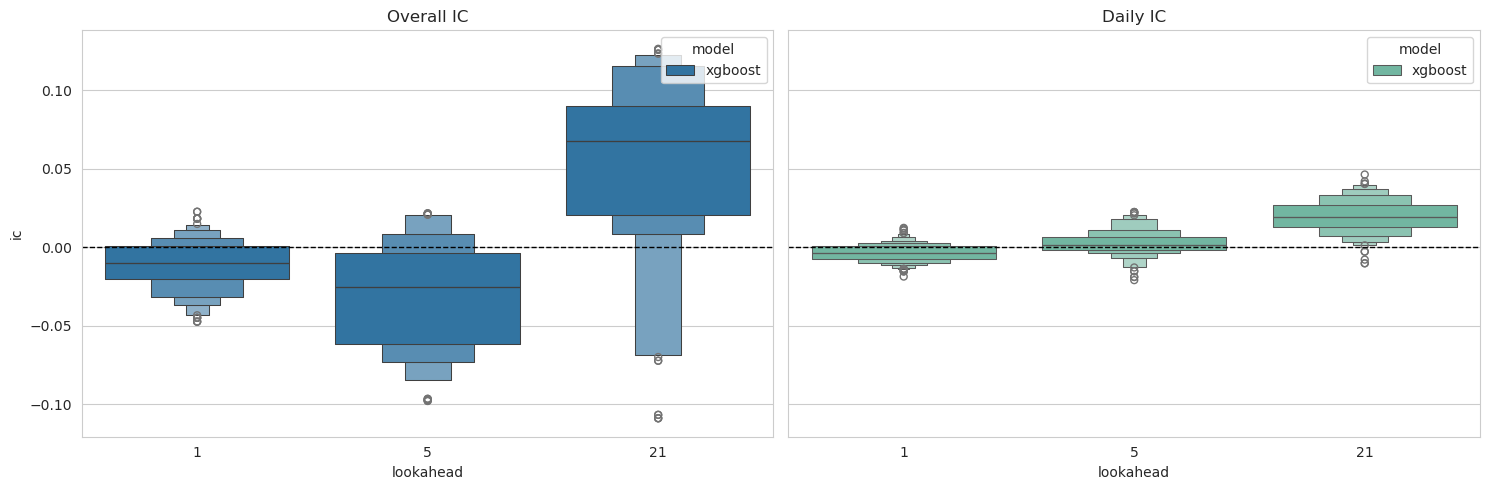

In [19]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 5), sharey=True)
sns.boxenplot(x='lookahead', y='ic', hue='model',
              data=xgb_metrics.assign(model='xgboost')
              , ax=axes[0])
axes[0].axhline(0, ls='--', lw=1, c='k')
axes[0].set_title('Overall IC')
sns.boxenplot(x='lookahead', y='ic', hue='model',
              data=xgb_daily_ic.assign(model='xgboost')
              , ax=axes[1], palette='Set2')
axes[1].axhline(0, ls='--', lw=1, c='k')
axes[1].set_title('Daily IC')
fig.tight_layout()

Let's compare it to the result from linear regression

In [20]:
# loading the parquet file with the linear regression results 
lr_store = Path(results_path / 'tuning_lr.parquet')
lr_metrics = pd.read_parquet(lr_store)


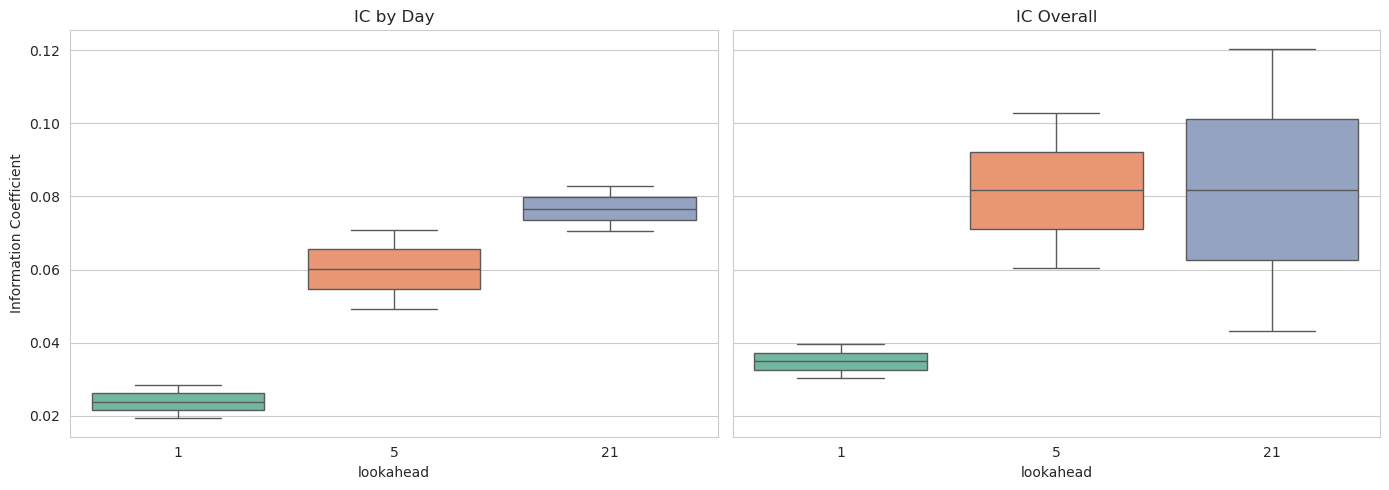

: 

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(14,5), sharey=True)

# plot average of daily IC values
sns.boxplot(x='lookahead', y='ic_by_day',data=lr_metrics, ax=axes[1], palette='Set2')
axes[0].set_title('IC by Day')

# plot IC across all predictions
sns.boxplot(x='lookahead', y='ic',data=lr_metrics, ax=axes[0], palette='Set2')
axes[1].set_title('IC Overall')
axes[0].set_ylabel('Information Coefficient')
axes[1].set_ylabel('')
fig.tight_layout()

Plot both side-to-side

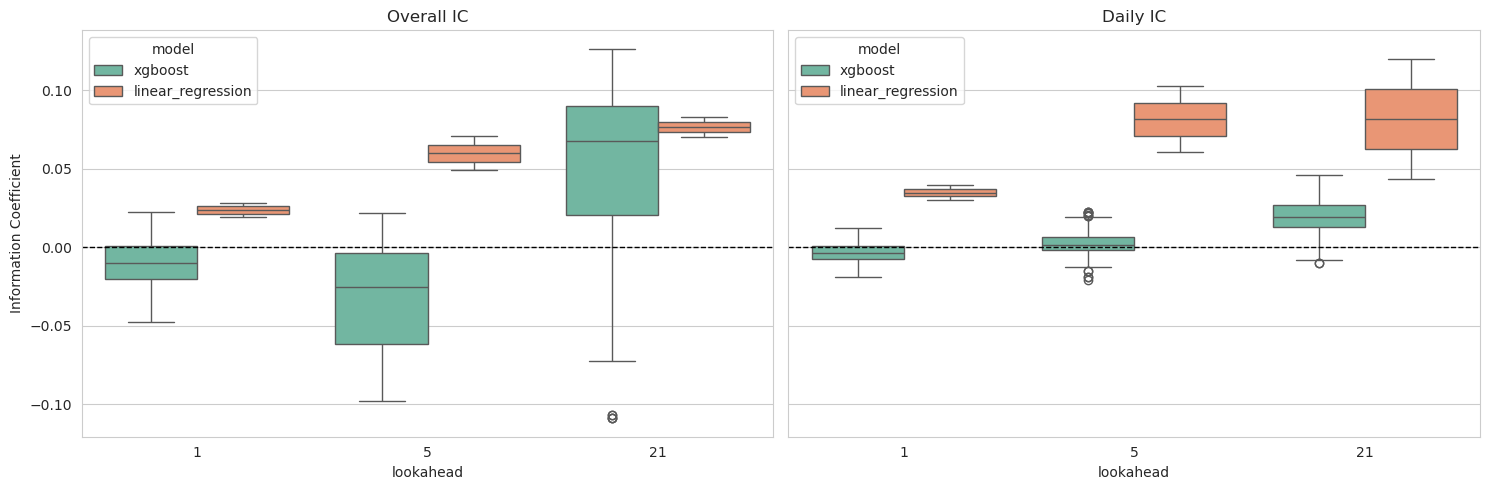

: 

In [ ]:
# Add a model column to distinguish between them
xgb_metrics_labeled = xgb_metrics.assign(model='xgboost')
xgb_daily_ic_labeled = xgb_daily_ic.assign(model='xgboost')
lr_metrics_labeled = lr_metrics.assign(model='linear_regression')

# Match column names where needed
lr_metrics_labeled = lr_metrics_labeled.rename(columns={'ic_by_day': 'ic_by_day', 'ic': 'ic'})

# Combine for overall IC
combined_ic = pd.concat([xgb_metrics_labeled[['lookahead', 'ic', 'model']],
                         lr_metrics_labeled[['lookahead', 'ic', 'model']]])

# Combine for daily IC
combined_daily_ic = pd.concat([xgb_daily_ic_labeled[['lookahead', 'ic', 'model']],
                               lr_metrics_labeled[['lookahead', 'ic_by_day']].rename(columns={'ic_by_day': 'ic'}).assign(model='linear_regression')])

fig, axes = plt.subplots(ncols=2, figsize=(15, 5), sharey=True)

# Plot overall IC
sns.boxplot(x='lookahead', y='ic', hue='model', data=combined_ic, ax=axes[0], palette='Set2')
axes[0].axhline(0, ls='--', lw=1, c='k')
axes[0].set_title('Overall IC')

# Plot daily IC
sns.boxplot(x='lookahead', y='ic', hue='model', data=combined_daily_ic, ax=axes[1], palette='Set2')
axes[1].axhline(0, ls='--', lw=1, c='k')
axes[1].set_title('Daily IC')

axes[0].set_ylabel('Information Coefficient')
axes[1].set_ylabel('')

fig.tight_layout()

## HyperParameter Impact: Linear Regression

Next, we'd like to understand if there's a systematic, statistical relationship between the hyperparameters and the outcomes across daily predictions. To this end, we will run a linear regression using the various XGBoost hyperparameter settings as dummy variables and the daily validation IC as the outcome.

The below chart shows the coefficient estimates and their confidence intervals for 1- and 21-day forecast horizons. 


In [19]:
lin_reg = {}
for t in [1, 21]:
    df_ = xgb_ic[xgb_ic.lookahead==t]
    y, X = df_.ic, df_.drop(['ic'], axis=1)
    X = sm.add_constant(pd.get_dummies(X, columns=X.columns, drop_first=True))
    model = sm.OLS(endog=y.astype(float), exog=X.astype(float))
    lin_reg[t] = model.fit()
    s = lin_reg[t].summary()
    coefs = pd.read_csv(StringIO(s.tables[1].as_csv())).rename(columns=lambda x: x.strip())
    coefs.columns = ['variable', 'coef', 'std_err', 't', 'p_value', 'ci_low', 'ci_high']
    coefs.to_csv(f'results/linreg_result_{t:02}.csv', index=False)

In [20]:
def visualize_lr_result(model, ax):
    ci = model.conf_int()
    errors = ci[1].sub(ci[0]).div(2)

    coefs = (model.params.to_frame('coef').assign(error=errors)
             .reset_index().rename(columns={'index': 'variable'}))
    coefs = coefs[~coefs['variable'].str.startswith('date')&(coefs.variable!='const')]

    coefs.plot(x='variable', y='coef', kind='bar', 
                 ax=ax, color='none', capsize=3,
                 yerr='error', legend=False)
    ax.set_ylabel('IC')
    ax.set_xlabel('')
    ax.scatter(x=np.arange(len(coefs)), marker='_', s=120, y=coefs['coef'], color='black')
    ax.axhline(y=0, linestyle='--', color='black', linewidth=1)
    ax.xaxis.set_ticks_position('none')

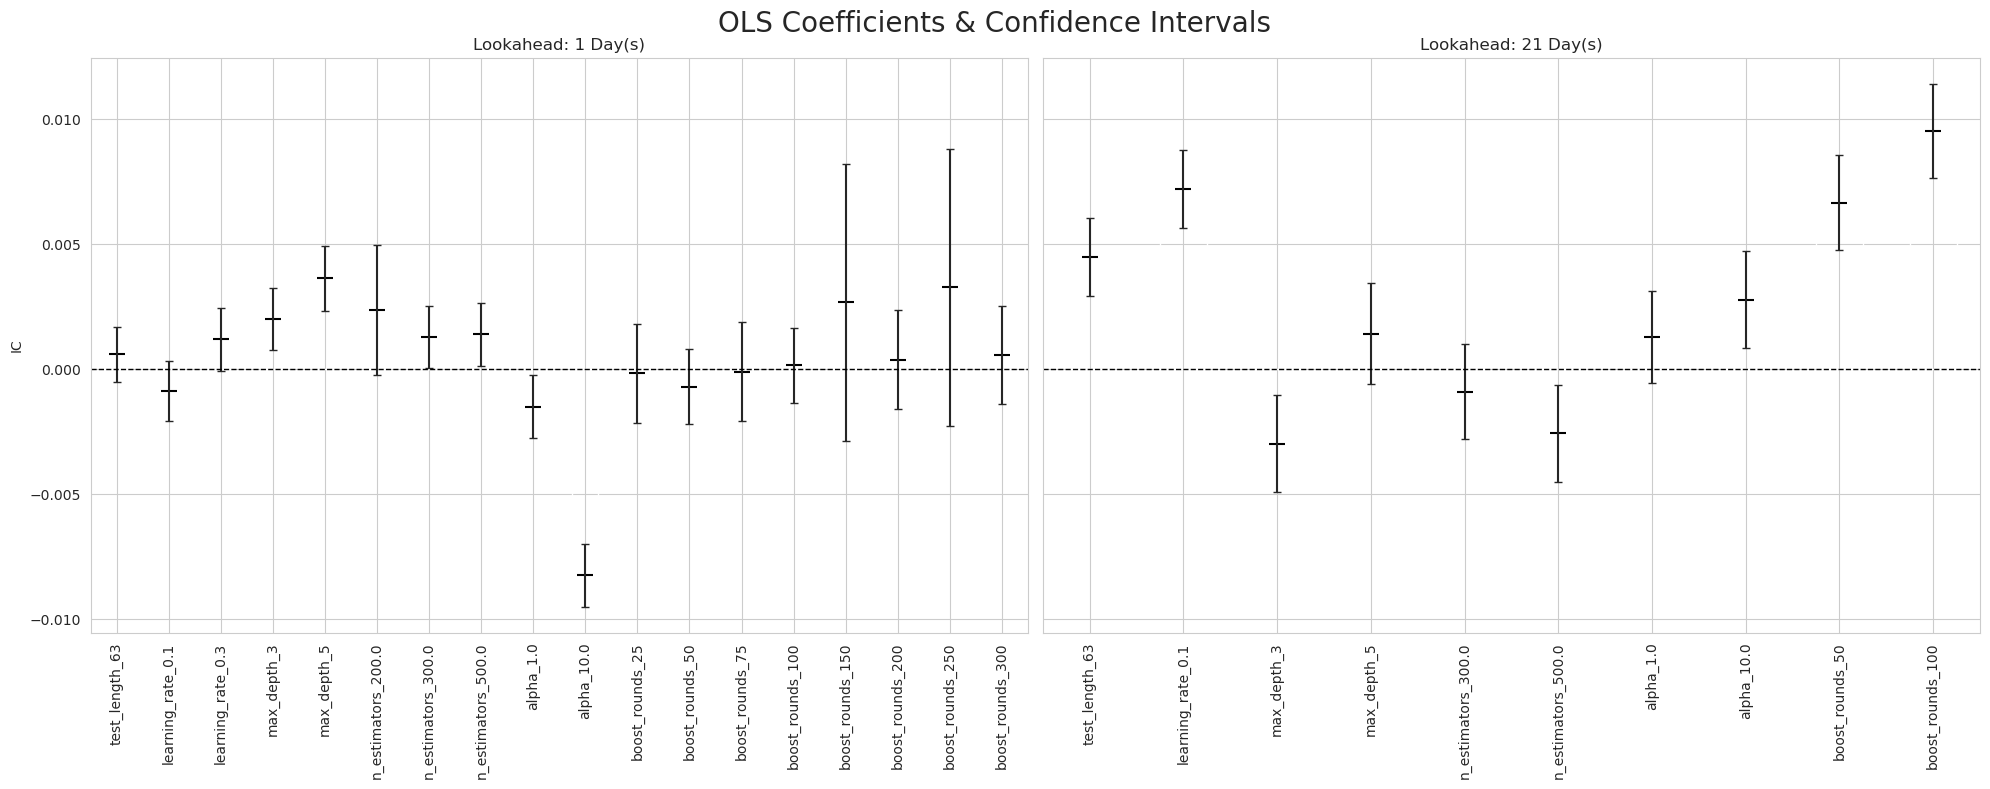

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8), sharey=True)
axes = axes.flatten()
for i, t in enumerate([1, 21]):
    visualize_lr_result(lin_reg[t], axes[i])
    axes[i].set_title(f'Lookahead: {t} Day(s)')
fig.suptitle('OLS Coefficients & Confidence Intervals', fontsize=20)
fig.tight_layout()
fig.subplots_adjust(top=.92);

## Cross-validation Result: Best Hyperparameters

### XGBoost

The top-performing XGBoost models use the following parameters for the three different prediction horizons.

In [22]:
group_cols = scope_params + xgb_train_params + ['boost_rounds']
xgb_daily_ic.groupby('lookahead', group_keys=False).apply(lambda x: x.nlargest(3, 'ic'))

,lookahead,train_length,test_length,learning_rate,max_depth,n_estimators,alpha,boost_rounds,ic
157,1,1134,21,0.3,5,500.0,0.0,300,0.012426
156,1,1134,21,0.3,5,500.0,0.0,200,0.011961
155,1,1134,21,0.3,5,500.0,0.0,100,0.011204
519,5,1134,21,0.1,5,100.0,0.0,100,0.022513
522,5,1134,21,0.1,5,300.0,0.0,100,0.022513
531,5,1134,21,0.1,5,500.0,0.0,100,0.022513
768,21,1134,63,0.1,5,100.0,0.0,100,0.046431
684,21,1134,21,0.1,3,500.0,10.0,100,0.042085
780,21,1134,63,0.1,5,500.0,10.0,100,0.040711


In [23]:
xgb_metrics.groupby('lookahead', group_keys=False).apply(lambda x: x.nlargest(3, 'ic'))
xgb_metrics.groupby('lookahead', group_keys=False).apply(lambda x: x.nlargest(3, 'ic')).to_csv('results/best_xgb_model.csv', index=False)

In [24]:
xgb_metrics.groupby('lookahead', group_keys=False).apply(lambda x: x.nlargest(3, 'daily_ic_mean'))

,lookahead,train_length,test_length,learning_rate,max_depth,n_estimators,alpha,daily_ic_mean,daily_ic_mean_n,daily_ic_median,daily_ic_median_n,avg_overfitting_ratio,avg_best_iteration,final_train_loss,final_valid_loss,boost_rounds,ic
155,1,1134,21,0.3,5.0,500.0,0.0,0.012426,300.0,0.020403,100.0,-1.588208,39.291667,0.183134,-0.071790,10,-0.015555
348,1,1134,21,0.3,5.0,500.0,0.0,0.012426,300.0,0.020403,100.0,-1.588208,39.291667,0.183134,-0.071790,50,0.013149
541,1,1134,21,0.3,5.0,500.0,0.0,0.012426,300.0,0.020403,100.0,-1.588208,39.291667,0.183134,-0.071790,100,0.013198
17,5,1134,21,0.1,5.0,500.0,0.0,0.022513,100.0,0.016030,100.0,-1.202446,11.666667,0.188616,-0.037219,10,-0.052315
20,5,1134,21,0.1,5.0,300.0,0.0,0.022513,100.0,0.016030,100.0,-1.202446,11.666667,0.188616,-0.037219,10,-0.052315
23,5,1134,21,0.1,5.0,100.0,0.0,0.022513,100.0,0.016030,100.0,-1.202446,11.666667,0.188616,-0.037219,10,-0.052315
47,21,1134,63,0.1,5.0,100.0,0.0,0.046431,100.0,0.045241,100.0,-1.093515,4.750000,0.330270,-0.034848,10,0.083916
240,21,1134,63,0.1,5.0,100.0,0.0,0.046431,100.0,0.045241,100.0,-1.093515,4.750000,0.330270,-0.034848,50,0.123550
433,21,1134,63,0.1,5.0,100.0,0.0,0.046431,100.0,0.045241,100.0,-1.093515,4.750000,0.330270,-0.034848,100,0.114010


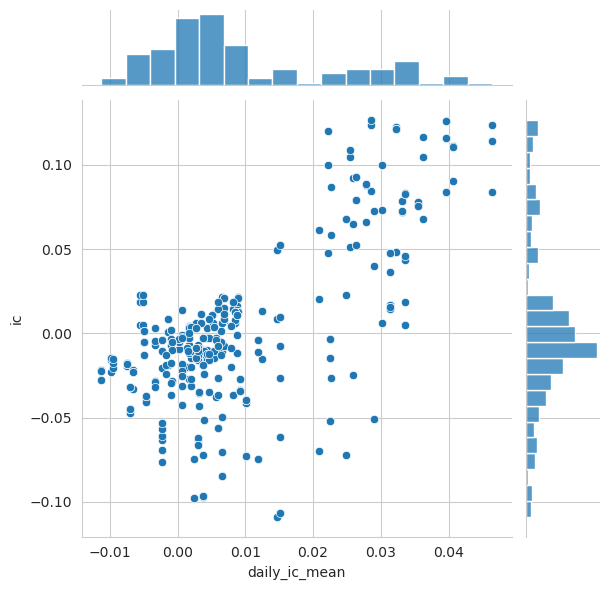

In [25]:
sns.jointplot(x=xgb_metrics.daily_ic_mean,y=xgb_metrics.ic)

### Visualization

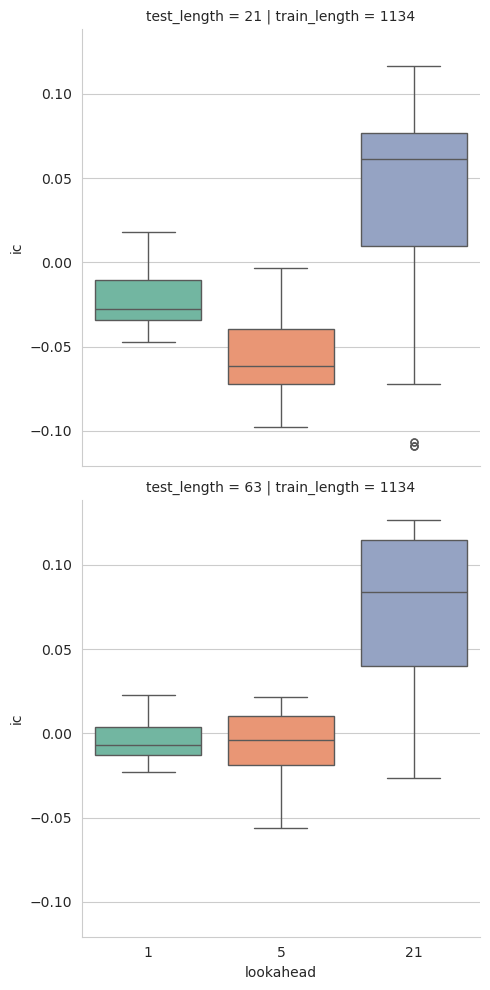

In [26]:
g = sns.catplot(x='lookahead', y='ic',
                col='train_length', row='test_length',
                data=xgb_metrics,
                kind='box',
                palette='Set2'
                )

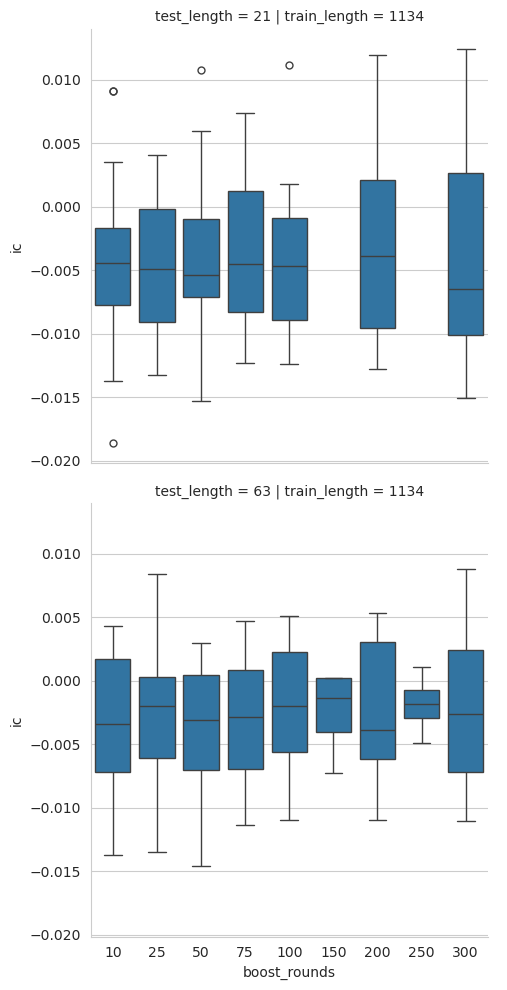

In [27]:
t=1
g=sns.catplot(x='boost_rounds',
            y='ic',
            col='train_length',
            row='test_length',
            data=xgb_daily_ic[xgb_daily_ic.lookahead == t],
            kind='box')
            #palette='Set2')

## AlphaLens Analysis - Validation Performance

### XGBoost

#### Select Parameters

In [28]:
xgb_daily_ic = pd.read_hdf('data/model_tuning.h5', 'xgb/daily_ic')
xgb_daily_ic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 781 entries, 0 to 780
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   lookahead      781 non-null    int64  
 1   train_length   781 non-null    int64  
 2   test_length    781 non-null    int64  
 3   learning_rate  781 non-null    float64
 4   max_depth      781 non-null    int64  
 5   n_estimators   781 non-null    float64
 6   alpha          781 non-null    float64
 7   boost_rounds   781 non-null    int64  
 8   ic             781 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 61.0 KB


In [29]:
def get_xgb_params(data, t=5, best=0):
    param_cols = scope_params[1:] + xgb_train_params + ['boost_rounds']
    df = data[data.lookahead==t].sort_values('ic', ascending=False).iloc[best]
    return df.loc[param_cols]

In [30]:
def get_xgb_key(t, p):
    key = f'{t}/{int(p.train_length)}/{int(p.test_length)}/{p.learning_rate}/'
    return key + f'{int(p.max_depth)}/{int(p.n_estimators)}/{int(p.alpha)}'

In [31]:
best_params = get_xgb_params(xgb_daily_ic, t=1, best=0)
best_params

train_length     1134.0
test_length        21.0
learning_rate       0.3
max_depth           5.0
n_estimators      500.0
alpha               0.0
boost_rounds      300.0
Name: 157, dtype: float64

In [32]:
best_params.to_hdf('data_yf.h5', 'best_params')

#### Plot rolling IC

In [33]:
def select_ic(params, ic_data, lookahead):
    return ic_data.loc[(ic_data.lookahead == lookahead) &
                       (ic_data.train_length == params.train_length) &
                       (ic_data.test_length == params.test_length) &
                       (ic_data.learning_rate == params.learning_rate) &
                       (ic_data.max_depth == params.max_depth) &
                       (ic_data.n_estimators == params.n_estimators) &
                       (ic_data.alpha == params.alpha) &
                       (ic_data.boost_rounds == params.boost_rounds), ['date', 'ic']].set_index('date')

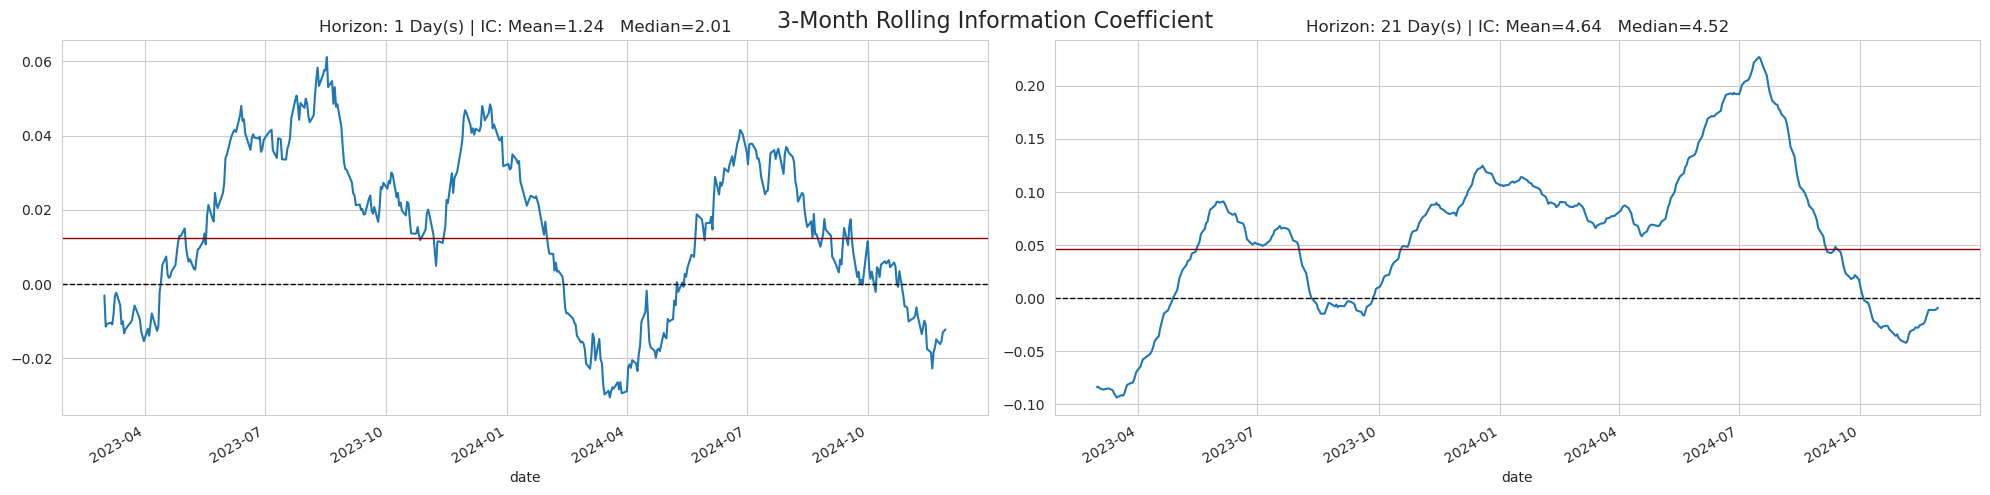

In [34]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
axes = axes.flatten()
for i, t in enumerate([1, 21]):
    params = get_xgb_params(xgb_daily_ic, t=t)
    data = select_ic(params, xgb_ic, lookahead=t).sort_index()
    rolling = data.rolling(63).ic.mean().dropna()
    avg = data.ic.mean()
    med = data.ic.median()
    rolling.plot(ax=axes[i], title=f'Horizon: {t} Day(s) | IC: Mean={avg*100:.2f}   Median={med*100:.2f}')
    axes[i].axhline(avg, c='darkred', lw=1)
    axes[i].axhline(0, ls='--', c='k', lw=1)

fig.suptitle('3-Month Rolling Information Coefficient', fontsize=16)
fig.tight_layout()
fig.subplots_adjust(top=0.92)

#### Get Predictions for Validation Period

We retrieve the predictions for the 10 validation runs:

In [35]:
lookahead = 1
topn = 5
for best in range(topn):
    best_params = get_xgb_params(xgb_daily_ic, t=lookahead, best=best)
    key = get_xgb_key(lookahead, best_params)
    rounds = str(int(best_params.boost_rounds))
    # make sure the file exists
    key_to_check = 'predictions/' + key
    with pd.HDFStore(results_path / 'tuning_xgb.h5', mode='r') as store:
        if key_to_check in store:
            if best == 0:
                best_predictions = pd.read_hdf(results_path / 'tuning_xgb.h5', 'predictions/' + key)
                best_predictions = best_predictions[rounds].to_frame(best)
            else:
                best_predictions[best] = pd.read_hdf(results_path / 'tuning_xgb.h5',
                                                    'predictions/' + key)[rounds]
        else:
            print(f"The key '{key_to_check}' does NOT exist in the HDF5 file.")
            continue
best_predictions = best_predictions.sort_index()


In [36]:
best_predictions.to_hdf('data/predictions.h5', f'xgb/train/{lookahead:02}')
best_predictions.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 49513 entries, ('AAL', Timestamp('2022-11-29 00:00:00')) to ('ZION', Timestamp('2023-04-11 00:00:00'))
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       49513 non-null  float32
 1   1       49513 non-null  float32
 2   2       49513 non-null  float32
 3   3       49513 non-null  float32
 4   4       49513 non-null  float32
dtypes: float32(5)
memory usage: 1.4+ MB


#### Get Trade Prices

Using next available prices.

In [39]:
def get_trade_prices(tickers):
    idx = pd.IndexSlice
    DATA_STORE = '../data/nasdaq_data_yf.h5'
    prices = (pd.read_hdf(DATA_STORE, 'nasdaq/price').swaplevel().sort_index())
    prices.index.names = ['symbol', 'date']
    return (prices.loc[idx[tickers, '2015': '2017'], 'open']
            .unstack('symbol')
            .sort_index()
            .shift(-1)
            .tz_localize('UTC'))

In [40]:
test_tickers = best_predictions.index.get_level_values('symbol').unique()

In [41]:
trade_prices = get_trade_prices(test_tickers)
trade_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 755 entries, 2015-01-02 00:00:00+00:00 to 2017-12-29 00:00:00+00:00
Columns: 155 entries, AAL to ZION
dtypes: float64(155)
memory usage: 920.2 KB


In [42]:
# persist result in case we want to rerun:
trade_prices.to_hdf('data/model_tuning.h5', 'trade_prices/model_selection')
trade_prices = pd.read_hdf('data/model_tuning.h5', 'trade_prices/model_selection')

We average the top five models and provide the corresponding prices to Alphalens, in order to compute the mean period-wise return earned on an equal-weighted portfolio invested in the daily factor quintiles for various holding periods:

In [43]:
factor = best_predictions.iloc[:, :5].mean(1).dropna().tz_localize('UTC', level='date').swaplevel()